<a href="https://colab.research.google.com/github/adasko-a/datascience_bootcamp/blob/main/case_studies/comparing_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


url = 'https://storage.googleapis.com/esmartdata-courses-files/ds-bootcamp/online_retail.xlsx'

retail_raw = pd.read_excel(url)
retail_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
retail = retail_raw.copy()
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [3]:
retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [4]:
retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [5]:
retail.dropna(inplace=True)
retail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [7]:
retail=retail[retail.Quantity >=0]

In [8]:
retail.CustomerID = retail.CustomerID.apply(lambda x: str(int(x)))
retail.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  object        
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 27.3+ MB


In [9]:
# SELECT * FROM retail;
retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [10]:
# SELECT Quantity, UnitProce, CustomerID FROM retail;
retail[['Quantity', 'UnitPrice', 'CustomerID']]

,Quantity,UnitPrice,CustomerID
0,6,2.55,17850
1,6,3.39,17850
2,8,2.75,17850
3,6,3.39,17850
4,6,3.39,17850
...,...,...,...
541904,12,0.85,12680
541905,6,2.10,12680
541906,4,4.15,12680
541907,4,4.15,12680


In [12]:
# SELECT Quantity, UnitProce, CustomerID FROM retail LIMIT 10;
retail[['Quantity', 'UnitPrice', 'CustomerID']][:10]

,Quantity,UnitPrice,CustomerID
0,6,2.55,17850
1,6,3.39,17850
2,8,2.75,17850
3,6,3.39,17850
4,6,3.39,17850
5,2,7.65,17850
6,6,4.25,17850
7,6,1.85,17850
8,6,1.85,17850
9,32,1.69,13047


In [13]:
# SELECT * FROM retail WHERE CustomerID ="17858";
retail[retail.CustomerID == "17858"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
8933,537156,84792,ENCHANTED BIRD COATHANGER 5 HOOK,3,2010-12-05 13:08:00,4.65,17858,United Kingdom
8934,537156,22173,METAL 4 HOOK HANGER FRENCH CHATEAU,5,2010-12-05 13:08:00,2.95,17858,United Kingdom
8935,537156,75013B,"STRING OF 8 BUTTERFLIES,PINK",4,2010-12-05 13:08:00,1.65,17858,United Kingdom
8936,537156,20829,GLITTER HANGING BUTTERFLY STRING,3,2010-12-05 13:08:00,2.10,17858,United Kingdom
8937,537156,22467,GUMBALL COAT RACK,4,2010-12-05 13:08:00,2.55,17858,United Kingdom
...,...,...,...,...,...,...,...,...
522628,580403,22120,WELCOME WOODEN BLOCK LETTERS,2,2011-12-04 11:56:00,9.95,17858,United Kingdom
522629,580403,22119,PEACE WOODEN BLOCK LETTERS,11,2011-12-04 11:56:00,1.95,17858,United Kingdom
522630,580403,21755,LOVE BUILDING BLOCK WORD,4,2011-12-04 11:56:00,6.25,17858,United Kingdom
522631,580403,21756,BATH BUILDING BLOCK WORD,1,2011-12-04 11:56:00,6.25,17858,United Kingdom


In [14]:
retail.query("CustomerID == '17858'")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
8933,537156,84792,ENCHANTED BIRD COATHANGER 5 HOOK,3,2010-12-05 13:08:00,4.65,17858,United Kingdom
8934,537156,22173,METAL 4 HOOK HANGER FRENCH CHATEAU,5,2010-12-05 13:08:00,2.95,17858,United Kingdom
8935,537156,75013B,"STRING OF 8 BUTTERFLIES,PINK",4,2010-12-05 13:08:00,1.65,17858,United Kingdom
8936,537156,20829,GLITTER HANGING BUTTERFLY STRING,3,2010-12-05 13:08:00,2.10,17858,United Kingdom
8937,537156,22467,GUMBALL COAT RACK,4,2010-12-05 13:08:00,2.55,17858,United Kingdom
...,...,...,...,...,...,...,...,...
522628,580403,22120,WELCOME WOODEN BLOCK LETTERS,2,2011-12-04 11:56:00,9.95,17858,United Kingdom
522629,580403,22119,PEACE WOODEN BLOCK LETTERS,11,2011-12-04 11:56:00,1.95,17858,United Kingdom
522630,580403,21755,LOVE BUILDING BLOCK WORD,4,2011-12-04 11:56:00,6.25,17858,United Kingdom
522631,580403,21756,BATH BUILDING BLOCK WORD,1,2011-12-04 11:56:00,6.25,17858,United Kingdom


In [15]:
# SELECT * FROM retail WHERE CustomerID ="17858" and UnitPrice > 5;
retail[(retail.CustomerID == "17858") & (retail.UnitPrice > 5)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
8943,537156,21340,CLASSIC METAL BIRDCAGE PLANT HOLDER,2,2010-12-05 13:08:00,12.75,17858,United Kingdom
8944,537156,21761,WOOD AND GLASS MEDICINE CABINET,1,2010-12-05 13:08:00,29.95,17858,United Kingdom
8948,537156,22830,UTILTY CABINET WITH HOOKS,1,2010-12-05 13:08:00,26.95,17858,United Kingdom
68073,541853,21463,MIRRORED DISCO BALL,4,2011-01-23 14:29:00,5.95,17858,United Kingdom
68074,541853,82483,WOOD 2 DRAWER CABINET WHITE FINISH,6,2011-01-23 14:29:00,5.95,17858,United Kingdom
...,...,...,...,...,...,...,...,...
522626,580403,23110,PARISIENNE KEY CABINET,2,2011-12-04 11:56:00,5.75,17858,United Kingdom
522627,580403,21754,HOME BUILDING BLOCK WORD,2,2011-12-04 11:56:00,6.25,17858,United Kingdom
522628,580403,22120,WELCOME WOODEN BLOCK LETTERS,2,2011-12-04 11:56:00,9.95,17858,United Kingdom
522630,580403,21755,LOVE BUILDING BLOCK WORD,4,2011-12-04 11:56:00,6.25,17858,United Kingdom


In [21]:
# SELECT * FROM retail WHERE InvoiceNo is not null
retail[retail.InvoiceNo.notnull()]
#retail[~retail.InvoiceNo.isnull()]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


In [22]:
# SELECT CustomerID, count(*) FROM retail GROUP BY CustomerID;
retail.groupby('CustomerID').size()

,0
CustomerID,
12346,1
12347,182
12348,31
12349,73
12350,17
...,...
18280,10
18281,7
18282,12


In [23]:
retail['Revenue'] = retail.Quantity * retail.UnitPrice

In [25]:
# SELECT CustomerID, avg(Revenue), count(*) FROM retail GROUP BY CustomerID;
retail.groupby('CustomerID').aggregate({'Revenue': np.mean, 'CustomerID': np.size}).rename(columns={'Revenue':'Revenue_Avg'})


/tmp/ipykernel_33616/2739724125.py:2: FutureWarning: The provided callable <function mean at 0x7821ca4914e0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  retail.groupby('CustomerID').aggregate({'Revenue': np.mean, 'CustomerID': np.size}).rename(columns={'Revenue':'Revenue_Avg'})


,Revenue_Avg,CustomerID
CustomerID,,
12346,77183.600000,1
12347,23.681319,182
12348,57.975484,31
12349,24.076027,73
12350,19.670588,17
...,...,...
18280,18.060000,10
18281,11.545714,7
18282,14.837500,12


In [28]:
retail.head().T

,0,1,2,3,4
InvoiceNo,536365,536365,536365,536365,536365
StockCode,85123A,71053,84406B,84029G,84029E
Description,WHITE HANGING HEART T-LIGHT HOLDER,WHITE METAL LANTERN,CREAM CUPID HEARTS COAT HANGER,KNITTED UNION FLAG HOT WATER BOTTLE,RED WOOLLY HOTTIE WHITE HEART.
Quantity,6,6,8,6,6
InvoiceDate,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00,2010-12-01 08:26:00
UnitPrice,2.55,3.39,2.75,3.39,3.39
CustomerID,17850,17850,17850,17850,17850
Country,United Kingdom,United Kingdom,United Kingdom,United Kingdom,United Kingdom
Revenue,15.3,20.34,22.0,20.34,20.34


In [29]:
retail['InvoiceDateDay'] = retail.InvoiceDate.dt.day

In [32]:
# # SELECT InvoiceDateDay, sum(Revenue) FROM retail GROUP BY InvoiceDateDay;
results = retail.groupby('InvoiceDateDay').aggregate({'Revenue': np.sum})

/tmp/ipykernel_33616/3329262555.py:2: FutureWarning: The provided callable <function sum at 0x7821ca490400> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  results = retail.groupby('InvoiceDateDay').aggregate({'Revenue': np.sum})


<Axes: xlabel='InvoiceDateDay'>

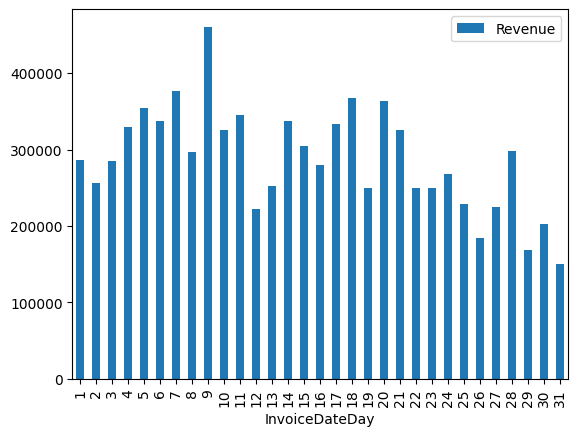

In [33]:
results.plot(kind='bar')

In [34]:
# SELECT * FROM retail ORDER BY Quantity DESC LIMIT 5;
retail.sort_values(by='Quantity', ascending=False).head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceDateDay
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6,9
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom,77183.6,18
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom,0.0,25
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901,United Kingdom,1008.0,27
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135,United Kingdom,3096.0,27


In [36]:
# SELECT * FROM retail ORDER BY Quantity LIMIT 5;
retail.nsmallest(5,'Quantity')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceDateDay
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311,United Kingdom,1.25,1
114,536381,22262,FELT EGG COSY CHICKEN,1,2010-12-01 09:41:00,0.85,15311,United Kingdom,0.85,1
115,536381,22637,PIGGY BANK RETROSPOT,1,2010-12-01 09:41:00,2.55,15311,United Kingdom,2.55,1
118,536381,21166,COOK WITH WINE METAL SIGN,1,2010-12-01 09:41:00,1.95,15311,United Kingdom,1.95,1
120,536381,37444A,YELLOW BREAKFAST CUP AND SAUCER,1,2010-12-01 09:41:00,2.95,15311,United Kingdom,2.95,1
